In [14]:
import json
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt


In [32]:
def get_metrics(stats, horizon=250):
    success = np.array([k['Success_Rate'] for k in stats])
    rzz = np.array([np.pad(np.array(k['Rzz_List'][:horizon]), (0,horizon - len(k['Rzz_List'][:horizon])), constant_values=1) for k in stats])
    
    succes_rate = np.mean(success)
    mean = rzz.mean(axis=1)

    trsh = np.cos(np.deg2rad(45))
    tt_trsh = np.where(np.argmax(rzz>trsh, axis=1) > 0, np.argmax(rzz>trsh, axis=1), rzz.shape[1])
    trsh_violation = 1 - np.sum(rzz>trsh, axis=1) / (min(horizon,400) - 150)

    return rzz, succes_rate, mean, tt_trsh, trsh_violation

### Picking the best policy 
1. Best Success for MH and PH
2. which one has more diverse rollouts 

MH exec
1800: 0.98
2000: 0.98
1400: 0.98
1200: 0.92
1000: 1.0
1600: 0.94


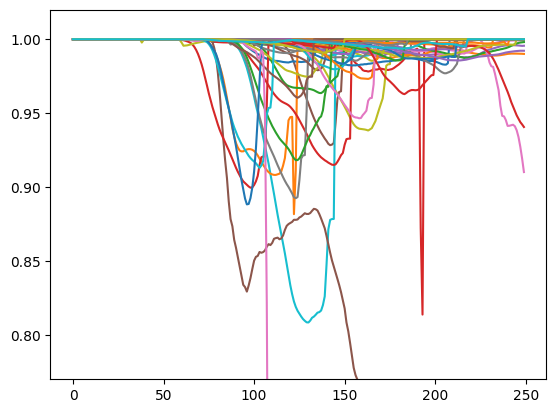

In [56]:
ph_path = Path('../outputs/can_rollouts/mh_success/')
print('MH exec')

for file in ph_path.iterdir():

    with (file / 'rollout_stats.json').open() as f:
        stats = json.load(f )
        rzz, succes_rate, mean, tt_trsh, trsh_violation = get_metrics(stats)
        epoch = file.name.removeprefix('model_epoch_').removesuffix('.pth')
        print(f'{epoch}: {succes_rate}')
plt.plot(rzz.T)
plt.ylim([0.77, 1.02])
plt.show()

PH_exec
1800: 1.0
2000: 1.0
1400: 0.98
1200: 0.98
1000: 0.98
1600: 1.0


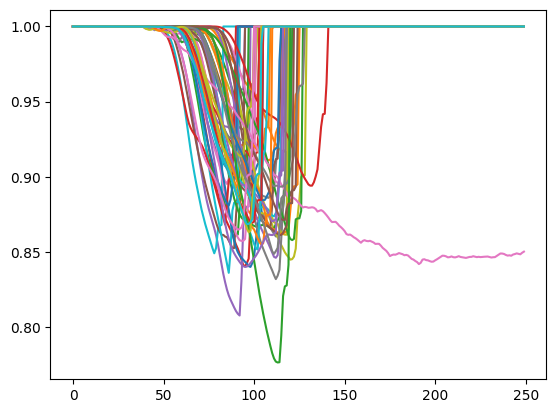

In [54]:
ph_path = Path('../outputs/can_rollouts/ph_success/')
print('PH_exec')

for file in ph_path.iterdir():

    with (file / 'rollout_stats.json').open() as f:
        stats = json.load(f )
        rzz, succes_rate, mean, tt_trsh, trsh_violation = get_metrics(stats)
        epoch = file.name.removeprefix('model_epoch_').removesuffix('.pth')
        print(f'{epoch}: {succes_rate}')
plt.plot(rzz.T)
plt.show()

#### Policy Diversity

1.0


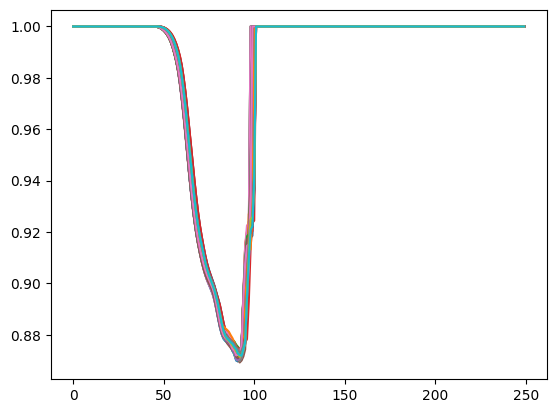

In [60]:
# Hardcoded stats file path (20:17 run)

stats_path = Path("../outputs/can_rollouts/policy_diversity_ph/rollout_stats.json")
with stats_path.open() as f:
    stats = json.load(f)

rzz, succes_rate, mean, tt_trsh, trsh_violation = get_metrics(stats)
print(succes_rate)
plt.plot(rzz.T)
plt.show()


1.0


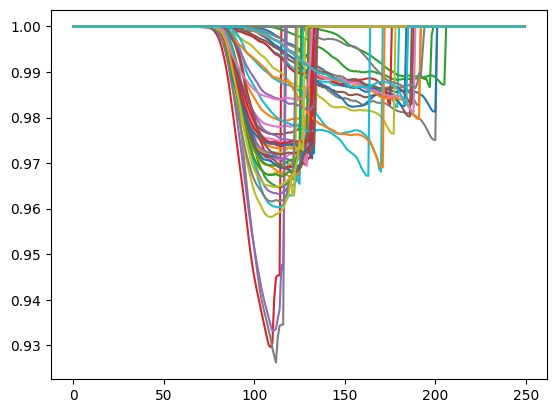

In [61]:
# Hardcoded stats file path (20:17 run)

stats_path = Path("../outputs/can_rollouts/policy_diversity_mh_h300/rollout_stats.json")
with stats_path.open() as f:
    stats = json.load(f)

rzz, succes_rate, mean, tt_trsh, trsh_violation = get_metrics(stats)
print(succes_rate)
plt.plot(rzz.T)
plt.show()
